[INFO] Zero-padding aktiv: N -> 3072


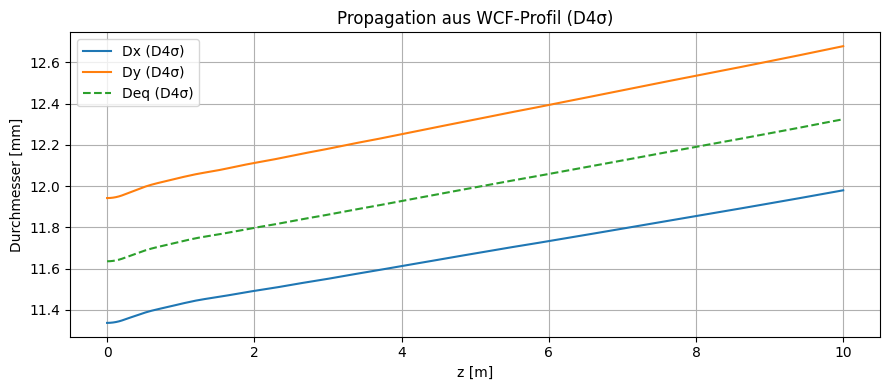

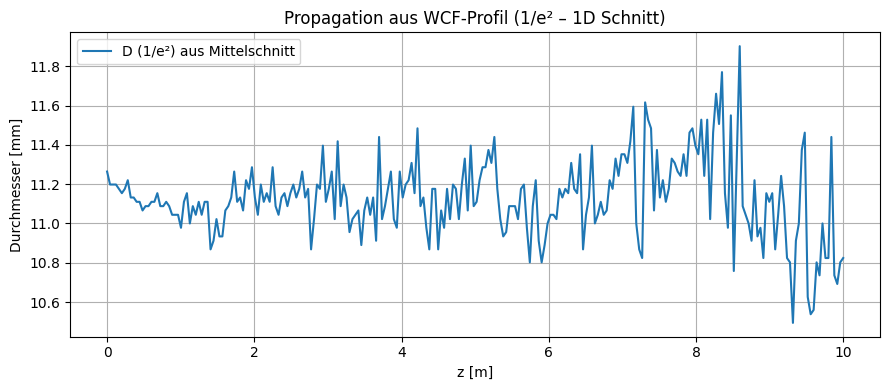

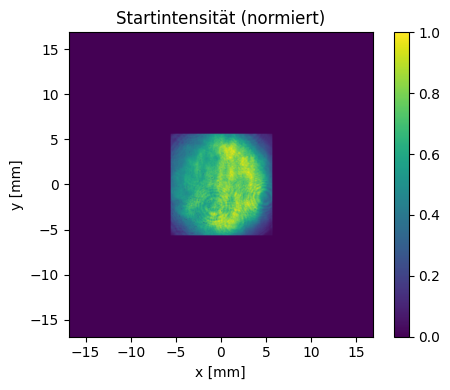

Done.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import struct
import os

# ==============================================================
# 1) PARAMETER & SETUP
# ==============================================================
lam = 1064e-9          # [m]
N   = 1024             # muss zur WCF passen

# ---- PHYSIKALISCHE SKALIERUNG: dein Strahl ~11 mm Durchmesser ----
TWO_W = 11e-3          # [m] (nur zur Skalierung des Gitters)
L     = 1.5 * TWO_W    # [m] Fenster etwas größer als Strahl
dx    = L / N

# Propagation in Vakuum (freie Propagation)
z1      = 0.0          # Start-Ebene in der Simulation (relativ)
z_max   = 8.0
z_steps = 120
z_array = np.linspace(z1, z_max, z_steps)

# gemessene/angenommene Wellenfrontkrümmung am Start (für Phase-Fall)
Rx = 300.0   # [m]  <--- hier deine Werte rein
Ry = 200.0   # [m]

# Koordinaten
x = (np.arange(N) - N/2) * dx
X, Y = np.meshgrid(x, x)

# ==============================================================
# 2) FUNKTIONEN
# ==============================================================

def extract_2d_profile_from_wcf(filename: str) -> np.ndarray:
    """WCF -> Amplitude sqrt(I) als komplexes Feld (Phase=0)."""
    if not os.path.exists(filename):
        raise FileNotFoundError(f"{filename} nicht gefunden!")

    FILE_HEADER  = 5592
    FRAME_HEADER = 944

    with open(filename, "rb") as f:
        f.seek(FILE_HEADER + FRAME_HEADER)
        data = f.read(N * N * 2)
        frame = np.frombuffer(data, dtype=np.uint16).reshape((N, N)).astype(np.float64)

    frame -= frame.min()
    frame[frame < 0] = 0.0
    mx = frame.max()
    frame = frame / mx if mx > 0 else frame

    return np.sqrt(frame).astype(np.complex128)

def apply_curvature_phase(U_amp: np.ndarray, Rx: float, Ry: float) -> np.ndarray:
    """U = A * exp(i*k/2*(x^2/Rx + y^2/Ry))"""
    k = 2*np.pi/lam
    term = np.zeros_like(X, dtype=np.float64)

    if np.isfinite(Rx) and abs(Rx) > 1e-12:
        term += (X**2) / Rx
    if np.isfinite(Ry) and abs(Ry) > 1e-12:
        term += (Y**2) / Ry

    return U_amp * np.exp(1j * k * 0.5 * term)

def propagate_asm(U: np.ndarray, dz: float) -> np.ndarray:
    """Angular Spectrum Propagation in Vakuum."""
    if dz == 0:
        return U
    k = 2*np.pi/lam
    fx = np.fft.fftfreq(N, d=dx)
    fy = np.fft.fftfreq(N, d=dx)
    FX, FY = np.meshgrid(fx, fy)
    kx = 2*np.pi*FX
    ky = 2*np.pi*FY
    kz = np.sqrt((k+0j)**2 - kx**2 - ky**2)
    H  = np.exp(1j * kz * dz)
    return np.fft.ifft2(np.fft.fft2(U) * H)

def d4sigma_mm(I: np.ndarray) -> float:
    """Isotrop gemittelter D4σ-Durchmesser in mm."""
    total = I.sum()
    if total <= 0:
        return np.nan

    P = I / total
    cx = np.sum(X * P)
    cy = np.sum(Y * P)

    sigma_sq = 0.5 * (np.sum(P * (X - cx)**2) + np.sum(P * (Y - cy)**2))
    return 4.0 * np.sqrt(max(sigma_sq, 0.0)) * 1e3  # mm

# ==============================================================
# 3) MAIN
# ==============================================================

def main():
    # --- Input: Realprofil aus WCF (Amplitude) ---
    try:
        U_amp = extract_2d_profile_from_wcf("BeamProfile1.wcf")
        print("WCF geladen: BeamProfile1.wcf")
    except Exception as e:
        print("WCF nicht geladen, Fallback:", e)
        Rr = np.sqrt(X**2 + Y**2)
        U_amp = np.exp(-(Rr/(TWO_W/2))**20).astype(np.complex128)

    # --- Fall A: ohne Phase (nur Amplitude, Phase=0) ---
    U0_no_phase = U_amp.copy()

    # --- Fall B: mit Phase aus (Rx,Ry) ---
    U0_with_phase = apply_curvature_phase(U_amp, Rx=Rx, Ry=Ry)

    # --- Propagation + D4σ ---
    d_no = []
    d_ph = []

    for z in z_array:
        Uz0 = propagate_asm(U0_no_phase, z)
        Uz1 = propagate_asm(U0_with_phase, z)

        d_no.append(d4sigma_mm(np.abs(Uz0)**2))
        d_ph.append(d4sigma_mm(np.abs(Uz1)**2))

    d_no = np.array(d_no)
    d_ph = np.array(d_ph)

    # ==========================================================
    # 4) PLOT (ein Plot, beide Kurven)
    # ==========================================================
    plt.figure(figsize=(11, 6))
    plt.plot(z_array, d_no, lw=2.5, label="ohne Phase (nur |U| aus WCF)")
    plt.plot(z_array, d_ph, lw=2.5, label=f"mit Phase (Rx={Rx:.1f} m, Ry={Ry:.1f} m)")
    plt.xlabel("Propagation z [m]")
    plt.ylabel("D4σ Durchmesser [mm]")
    plt.title(
        "Freie Propagation (Angular Spectrum) – Realprofil\n"
        f"L={L*1e3:.1f} mm, dx={dx*1e6:.1f} µm, λ={lam*1e9:.1f} nm"
    )
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()
